# Zadanie Podsumowujące: Cyfrowa autopsja – co ukrywa plik?

**Kontekst kliniczny:**
Otrzymałeś plik DICOM o nazwie `tajemnicze_badanie.dcm`. Z nagłówka usunięto tagi z opisem badania oraz nazwą procedury (tzw. ślepa próba). 

Twoim zadaniem jest przeprowadzenie fizycznej i wizualnej analizy tego obrazu, aby wywnioskować, na jaką część ciała pacjenta patrzysz. Wykorzystaj wiedzę o skali Hounsfielda i okienkowaniu, aby "wydobyć" z pliku ukryte informacje.

In [3]:
# Import niezbędnych bibliotek
import pydicom
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

### Krok 1: Odczyt techniczny
1. Wczytaj plik `tajemnicze_badanie.dcm`.
2. Wydrukuj wymiary macierzy (`Rows`, `Columns`), rozmiar piksela (`PixelSpacing`) oraz grubość warstwy (`SliceThickness`).
3. Wydrukuj parametry kalibracyjne `RescaleSlope` oraz `RescaleIntercept` (jeśli ich nie ma, przyjmij domyślnie m=1, b=0).

In [26]:
# Miejsce na Twój kod (Krok 1):
ds = pydicom.dcmread('tajemnicze_badanie.dcm')
print(f'Rozmiar: {ds.Rows} x {ds.Columns} pixeli')
print(f'Rozmiar pixela: {ds.PixelSpacing[0]} x {ds.PixelSpacing[1]} mm')
print(f'Parametry kalibracyjne - slope: {ds.RescaleSlope}; Intercept: {ds.RescaleIntercept}')

Rozmiar: 512 x 512 pixeli
Rozmiar pixela: 005.429688e-01 x 005.429688e-01 mm
Parametry kalibracyjne - slope: 1; Intercept: -1024


### Krok 2: Przejście na fizyczną skalę HU
Przelicz surowe wartości pikseli z detektora na obiektywne jednostki Hounsfielda (HU) korzystając ze wzoru na transformację liniową. 
Wydrukuj minimalną i maksymalną wartość HU w całym przekroju.

In [32]:
# Miejsce na Twój kod (Krok 2):
image_hu = ds.pixel_array * ds.RescaleSlope + ds.RescaleIntercept
print(f'max: {np.max(image_hu)}')
print(f'min: {np.min(image_hu)}')

max: 1627.0
min: -1024.0


### Krok 3: Analiza widma (Histogram)
Narysuj histogram wartości HU dla przeliczonego obrazu. 
- Ustaw liczbę koszyków (`bins`) na co najmniej 200.
- Ogranicz oś X do przedziału od -1200 do +1500 HU (użyj `plt.xlim()`), aby odrzucić skrajne wartości odstające (np. artefakty z obudowy tomografu).

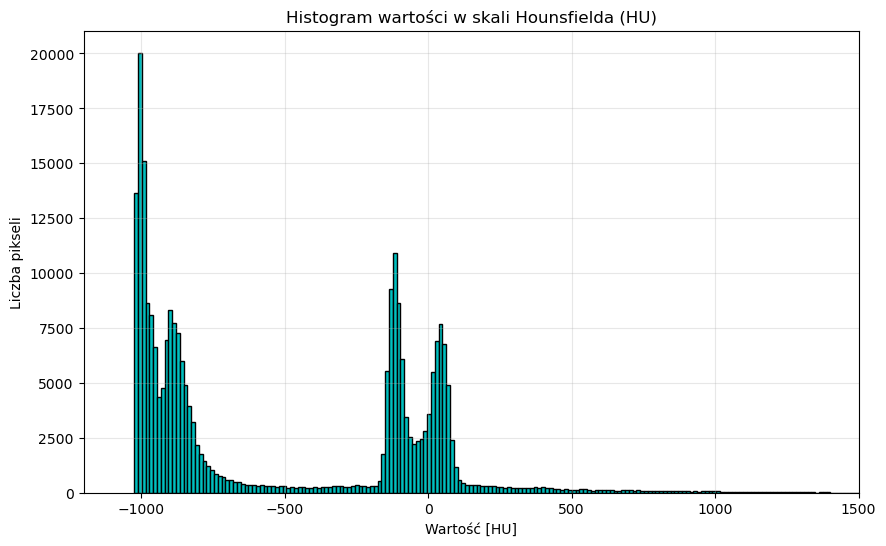

In [38]:
# Miejsce na Twój kod (Krok 3):
# Rysujemy histogram wartości Hounsfielda
plt.hist(image_hu.flatten(), bins=200, color='c', edgecolor='black')
plt.title('Histogram wartości w skali Hounsfielda (HU)')
plt.xlabel('Wartość [HU]')
plt.ylabel('Liczba pikseli')
plt.xlim(-1200, 1500)
plt.grid(True, alpha=0.3)
plt.show()

**Pytanie do przemyślenia:** Patrząc na powyższy histogram, zidentyfikuj główne "piki" (zgrupowania pikseli). Jakiej klasie tkanek (powietrze, woda/tkanki miękkie, kość) one odpowiadają?

*(Odpowiedz w tej komórce klikając dwukrotnie)*
- Pik 1 (ok. -1000 HU) to prawdopodobnie: powietrze
- Pik 2 (ok. -900 do -800 HU) to prawdopodobnie: tkanka płucna
- Pik 3 (ok. -100 do -50 HU) to prawdopodobnie: tkanka tłuszczowa
- Pik 4 (ok. 20 do 60 HU) to prawdopodobnie: woda

### Krok 4: Matryca diagnostyczna
Poniżej znajduje się gotowa funkcja `apply_window`. Użyj jej, aby wygenerować siatkę 2x2 (za pomocą `plt.subplots`), na której wyświetlisz ten sam obraz w czterech skrajnie różnych oknach:
1. **Okno płucne** (WW: 1500, WL: -600)
2. **Okno miękkie/śródpiersia** (WW: 400, WL: 40)
3. **Okno kostne** (WW: 1500, WL: 300)
4. **Okno mózgowe** (WW: 80, WL: 40)

Pamiętaj o dodaniu odpowiednich tytułów i wyłączeniu osi (axis off).

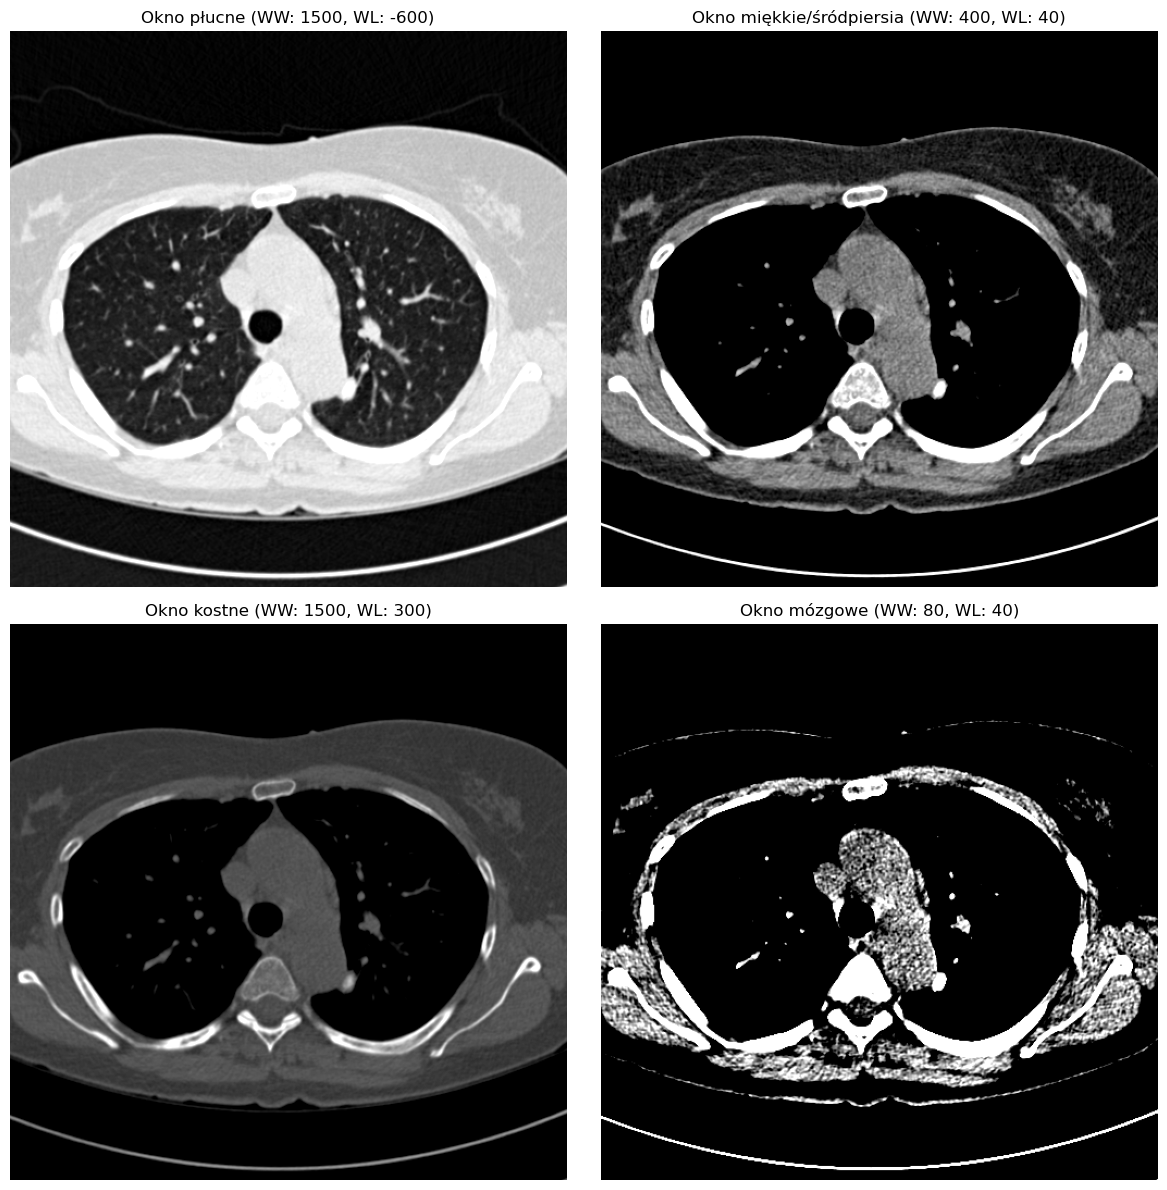

In [44]:
def apply_window(image, window_width, window_level):
    min_val = window_level - window_width / 2
    max_val = window_level + window_width / 2
    windowed = np.clip(image, min_val, max_val)
    windowed = ((windowed - min_val) / (max_val - min_val)) * 255.0
    return windowed.astype(np.uint8)

# Miejsce na Twój kod (Krok 4 - Rysowanie siatki subplots):
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Uzupełnij komórki axes[0,0], axes[0,1] itd.
# 1. Zastosowanie funkcji dla każdego z 4 okien klinicznych
img_lung = apply_window(image_hu, window_width=1500, window_level=-600)
img_soft = apply_window(image_hu, window_width=400, window_level=40)
img_bone = apply_window(image_hu, window_width=1500, window_level=300)
img_brain = apply_window(image_hu, window_width=80, window_level=40)

# [0, 0] Lewy górny - Okno płucne
axes[0, 0].imshow(img_lung, cmap='gray')
axes[0, 0].set_title('Okno płucne (WW: 1500, WL: -600)')
axes[0, 0].axis('off')

# [0, 1] Prawy górny - Okno śródpiersia (miękkie)
axes[0, 1].imshow(img_soft, cmap='gray')
axes[0, 1].set_title('Okno miękkie/śródpiersia (WW: 400, WL: 40)')
axes[0, 1].axis('off')

# [1, 0] Lewy dolny - Okno kostne
axes[1, 0].imshow(img_bone, cmap='gray')
axes[1, 0].set_title('Okno kostne (WW: 1500, WL: 300)')
axes[1, 0].axis('off')

# [1, 1] Prawy dolny - Okno mózgowe
axes[1, 1].imshow(img_brain, cmap='gray')
axes[1, 1].set_title('Okno mózgowe (WW: 80, WL: 40)')
axes[1, 1].axis('off')

# Automatyczne ułożenie marginesów i wyświetlenie
plt.tight_layout()
plt.show()

### Krok 5: Wniosek końcowy (Diagnoza)
Na podstawie analizy geometrycznej, rozkładu gęstości HU na histogramie oraz wizualnej matrycy w 4 różnych oknach, odpowiedz na pytanie głównę:

**Jaką okolicę anatomiczną (część ciała) przedstawia ten przekrój?** 
Uzasadnij swoją odpowiedź odwołując się do fizyki obrazu (np. "W oknie X zaobserwowałem dużą ilość struktury o gęstości Y, co sugeruje, że jest to...").

*(Napisz swoją diagnozę poniżej)*

**Moja diagnoza:**
[Twoja odpowiedź...]